# Market Microstructure Analysis of Bitcoin Order Flow

This project analyzes Bitcoin trading activity to see whether buying and selling pressure helps explain short-term price movements.

The goal is to study how market activity, trading volume, and short-term returns interact in a liquid electronic market.

In [44]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Data Collection

I used one-minute Bitcoin market data from Yahoo Finance over a seven-day period. The dataset includes open, high, low, close, and trading volume information for each interval.

In [45]:
# ==========================================
# DOWNLOAD BTC MINUTE DATA
# ==========================================

btc = yf.download(
    "BTC-USD",
    period="7d",
    interval="1m",
    auto_adjust=True
)

print(btc.shape)

btc.head()

[*********************100%***********************]  1 of 1 completed

(9058, 5)


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Datetime,,,,,
2026-05-15 00:00:00+00:00,81090.757812,81094.882812,81070.031250,81081.960938,0
2026-05-15 00:01:00+00:00,81075.062500,81088.710938,81074.023438,81075.976562,123650048
2026-05-15 00:02:00+00:00,81112.867188,81132.000000,81077.023438,81077.023438,0
2026-05-15 00:03:00+00:00,81121.476562,81143.023438,81120.367188,81120.367188,0
2026-05-15 00:04:00+00:00,81124.617188,81130.007812,81110.062500,81121.492188,0


In [46]:
btc = btc.reset_index()

btc.columns = [
    'datetime',
    'close',
    'high',
    'low',
    'open',
    'volume'
]

btc = btc[
    ['datetime', 'open', 'high', 'low', 'close', 'volume']
]

print(btc.shape)

display(btc.head())

(9058, 6)


,datetime,open,high,low,close,volume
0,2026-05-15 00:00:00+00:00,81081.960938,81094.882812,81070.031250,81090.757812,0
1,2026-05-15 00:01:00+00:00,81075.976562,81088.710938,81074.023438,81075.062500,123650048
2,2026-05-15 00:02:00+00:00,81077.023438,81132.000000,81077.023438,81112.867188,0
3,2026-05-15 00:03:00+00:00,81120.367188,81143.023438,81120.367188,81121.476562,0
4,2026-05-15 00:04:00+00:00,81121.492188,81130.007812,81110.062500,81124.617188,0


## Data Cleaning

The raw dataset contained many intervals with zero trading volume. These rows were removed because they do not represent active trading and would distort order-flow calculations.

I also verified:
- missing values
- timestamp consistency
- return calculations
- volume distributions

In [47]:
print(btc.isnull().sum())

datetime    0
open        0
high        0
low         0
close       0
volume      0
dtype: int64


In [48]:
# ==========================================
# REMOVE ZERO-VOLUME INTERVALS
# ==========================================

before = len(btc)

btc = btc[btc['volume'] > 0].copy()

after = len(btc)

print("Rows before:", before)
print("Rows after:", after)

print("\nRemaining zero-volume rows:")
print((btc['volume'] == 0).sum())

Rows before: 9058
Rows after: 2246

Remaining zero-volume rows:
0


## Signed Volume Construction

Because Yahoo Finance does not provide full order-book data, I created a signed-volume proxy to estimate directional trading pressure.

Positive values represent upward price movement during the interval, while negative values represent downward movement.

In [49]:
btc['direction'] = np.where(
    btc['close'] > btc['open'],
    1,
    -1
)

btc['signed_volume_proxy'] = (
    btc['direction'] *
    btc['volume']
)

btc[['close', 'volume', 'direction', 'signed_volume_proxy']].head()

,close,volume,direction,signed_volume_proxy
1,81075.062500,123650048,-1,-123650048
5,81152.976562,7823360,1,7823360
10,81283.101562,8663040,-1,-8663040
18,81383.523438,6291456,-1,-6291456
19,81413.109375,1515520,1,1515520


In [50]:
btc['signed_volume_zscore'] = (
    btc['signed_volume_proxy']
    - btc['signed_volume_proxy'].mean()
) / btc['signed_volume_proxy'].std()

print(btc['signed_volume_zscore'].describe())

count    2.246000e+03
mean     1.107257e-17
std      1.000000e+00
min     -1.728567e+01
25%     -2.011733e-01
50%      2.692265e-03
75%      2.169164e-01
max      8.008444e+00
Name: signed_volume_zscore, dtype: float64


## Return Construction

I calculated log returns using consecutive minute prices.

Log returns are standard in finance because they handle compounding naturally and make short-term return behavior easier to analyze statistically.

In [52]:
# ==========================================
# REBUILD RETURNS
# ==========================================

btc['returns'] = np.log(
    btc['close'] /
    btc['close'].shift(1)
)

print(btc['returns'].describe())

count    2245.000000
mean       -0.000020
std         0.000839
min        -0.008011
25%        -0.000415
50%         0.000006
75%         0.000372
max         0.006711
Name: returns, dtype: float64


In [53]:
# ==========================================
# STANDARDIZE OFI
# ==========================================

btc['signed_volume_lag1'] = (
    btc['signed_volume_zscore'].shift(1)
)

btc['future_return'] = (
    btc['returns'].shift(-1)
)

btc = btc.dropna().copy()

print(
    btc[
        [
            'signed_volume_zscore',
            'signed_volume_lag1',
            'returns',
            'future_return'
        ]
    ].head()
)

    signed_volume_zscore  signed_volume_lag1   returns  future_return
5               0.071079           -1.096054  0.000961       0.001602
10             -0.075276            0.071079  0.001602       0.001235
18             -0.054223           -0.075276  0.001235       0.000363
19              0.015082           -0.054223  0.000363      -0.000852
21             -0.358060            0.015082 -0.000852       0.001040


## Predictive Modeling

To avoid look-ahead bias, I shifted the signed-volume signal backward by one period and future returns forward by one period.

This allowed me to test whether previous trading pressure helps explain future price movements.

In [54]:
# ==========================================
# LAGGED PREDICTIVE FEATURES
# ==========================================

btc['signed_volume_lag1'] = (
    btc['signed_volume_zscore'].shift(1)
)

btc['future_return'] = (
    btc['returns'].shift(-1)
)

btc = btc.dropna().copy()

print(
    btc[
        [
            'signed_volume_zscore',
            'signed_volume_lag1',
            'returns',
            'future_return'
        ]
    ].head()
)

    signed_volume_zscore  signed_volume_lag1   returns  future_return
10             -0.075276            0.071079  0.001602       0.001235
18             -0.054223           -0.075276  0.001235       0.000363
19              0.015082           -0.054223  0.000363      -0.000852
21             -0.358060            0.015082 -0.000852       0.001040
23              0.067952           -0.358060  0.001040      -0.000145


In [ ]:
slope, intercept, r_value, p_value, std_err = linregress(
    btc['signed_volume_lag1'],
    btc['future_return']
)

print("Predictive Slope:", slope)
print("Predictive R-squared:", r_value**2)
print("Predictive P-value:", p_value)
print("Standard Error:", std_err)

Predictive Slope: 2.410353922362567e-05
Predictive R-squared: 0.0008243511800043586
Predictive P-value: 0.1752061680220232
Standard Error: 1.7774220801483267e-05


## Correlation Analysis

I computed the correlation between lagged signed-volume measures and future returns to evaluate whether directional trading pressure was associated with subsequent price changes.

In [55]:
correlation = btc[
    ['signed_volume_lag1', 'future_return']
].corr()

print(correlation)

                    signed_volume_lag1  future_return
signed_volume_lag1            1.000000       0.029358
future_return                 0.029358       1.000000


In [56]:
# ==========================================
# BINNED SIGNED VOLUME ANALYSIS
# ==========================================

btc['volume_bucket'] = pd.qcut(
    btc['signed_volume_lag1'],
    q=10,
    labels=False
)

bucket_returns = btc.groupby(
    'volume_bucket'
)['future_return'].mean()

print(bucket_returns)

volume_bucket
0   -0.000069
1    0.000009
2   -0.000078
3    0.000015
4   -0.000008
5   -0.000028
6   -0.000081
7    0.000022
8    0.000039
9   -0.000030
Name: future_return, dtype: float64


## Decile Analysis

To better understand the relationship between trading pressure and returns, I grouped observations into deciles based on signed-volume intensity and compared the average future return within each group.

The relationship was noisy and non-linear, which is common in financial markets.

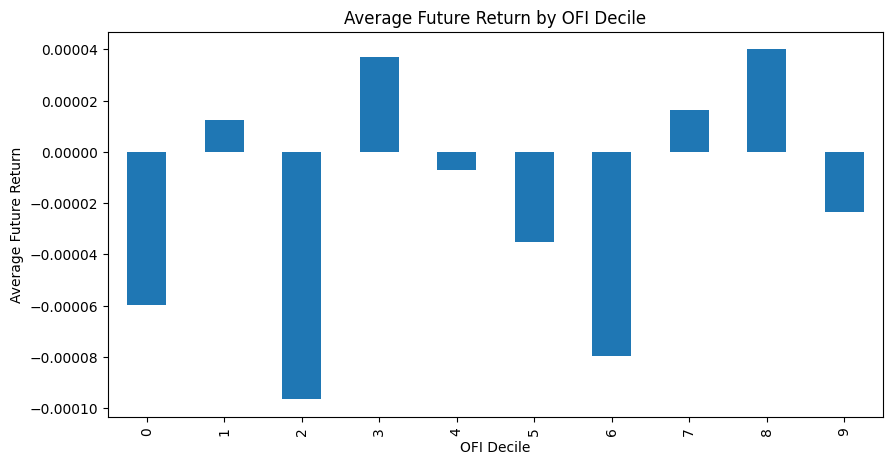

In [ ]:
plt.figure(figsize=(10,5))

bucket_returns.plot(kind='bar')

plt.title(
    "Average Future Return by OFI Decile"
)

plt.xlabel("OFI Decile")
plt.ylabel("Average Future Return")

plt.show()

## Conclusions

The analysis found evidence that trading pressure is related to contemporaneous price movement, but showed only weak predictive power for future returns.

Overall, the results suggest that information is incorporated rapidly into liquid cryptocurrency markets, making short-term return prediction difficult.